<a href="https://colab.research.google.com/github/NanditaPatil-dotcom/PhysSAE/blob/main/PhysSAE_Two_sided_alignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Setup

In [1]:
import os, time, math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.decomposition import PCA

# reproducibility
torch.manual_seed(0); np.random.seed(0)
torch.set_num_threads(4)

# publication style
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 220,
    "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
})

os.makedirs("artifacts", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# hyperparams
HIDDEN = 40        # PINN hidden width
N_LAYERS = 4       # number of hidden linear layers
DICT = 128         # SAE dictionary size (overcomplete 3.2x)
LAM_L1 = 5e-2      # SAE sparsity penalty
SAE_EPOCHS = 500
PINN_ITERS = 4000


# 2. PINN architecture


In [2]:
class PINN(nn.Module):
    def __init__(self, out_dim=1, layers=None):
        super().__init__()

        layers = layers or ([2] +[HIDDEN]*N_LAYERS +[out_dim])

        self.net = nn.ModuleList(
            [nn.Linear(layers[i], layers[i+1])
             for i in range(len(layers)-1)]
        )

        self.act = nn.Tanh()

        for m in self.net:
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)

        self._hidden = None

    def forward(self,x,t):
        h = torch.cat([x,t],dim=1)

        for layer in self.net[:-1]:
            h = self.act(layer(h))

        self._hidden = h

        return self.net[-1](h)


# 3. Training PINN

In [3]:
def train_pinn(loss_fn, n_iter=PINN_ITERS, log_every=400, tag="pinn",out_dim=1):
    model = PINN(out_dim=out_dim)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    hist = []; t0 = time.time()
    for it in range(n_iter):
        opt.zero_grad()
        loss, parts = loss_fn(model)
        loss.backward(); opt.step()
        hist.append(parts)
        if it % log_every == 0:
            print(f"[{tag}] it {it:5d} | bc {parts[0]:.2e} ic {parts[1]:.2e} f {parts[2]:.2e} | {time.time()-t0:.0f}s")
    print(f"[{tag}] total {time.time()-t0:.0f}s")
    return model, np.array(hist)

# 4. Train on PDEs

## 1. Train the Burgers PINN



In [4]:
nu = 0.01/np.pi
def burgers_loss(model):
    n_b, n_i, n_f = 100, 100, 2500
    x_b1 = -torch.ones(n_b,1); x_b2 = torch.ones(n_b,1); t_b = torch.rand(n_b,1)
    x_i = torch.rand(n_i,1)*2-1; t_i = torch.zeros(n_i,1); u_i = -torch.sin(np.pi*x_i)
    x_f = torch.rand(n_f,1)*2-1; t_f = torch.rand(n_f,1)
    u_b1, u_b2, u_ip = model(x_b1, t_b), model(x_b2, t_b), model(x_i, t_i)
    xfg, tfg = x_f.clone().requires_grad_(True), t_f.clone().requires_grad_(True)
    u = model(xfg, tfg)
    u_t = torch.autograd.grad(u, tfg, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, xfg, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xfg, torch.ones_like(u_x), create_graph=True)[0]
    r = u_t + u*u_x - nu*u_xx
    l_bc = (u_b1**2).mean() + (u_b2**2).mean()
    l_ic = ((u_ip - u_i)**2).mean()
    l_f  = (r**2).mean()
    return 100*l_bc + 100*l_ic + l_f, (l_bc.item(), l_ic.item(), l_f.item())

if os.path.exists("artifacts/burgers_pinn.pt"):
    pinn_b = PINN(out_dim=1); pinn_b.load_state_dict(torch.load("artifacts/burgers_pinn.pt"))
    hist_b = np.load("artifacts/burgers_hist.npy")
    print("Loaded cached Burgers PINN.")
else:
    pinn_b, hist_b = train_pinn(burgers_loss, tag="burgers")
    torch.save(pinn_b.state_dict(), "artifacts/burgers_pinn.pt")
    np.save("artifacts/burgers_hist.npy", hist_b)


[burgers] it     0 | bc 1.10e-02 ic 5.70e-01 f 1.29e-02 | 0s
[burgers] it   400 | bc 1.10e-03 ic 8.67e-03 f 7.04e-01 | 29s
[burgers] it   800 | bc 4.77e-04 ic 7.83e-04 f 4.56e-01 | 59s
[burgers] it  1200 | bc 3.47e-04 ic 3.61e-04 f 4.19e-01 | 87s
[burgers] it  1600 | bc 1.82e-04 ic 1.95e-04 f 4.21e-01 | 116s
[burgers] it  2000 | bc 1.11e-04 ic 2.32e-04 f 4.05e-01 | 145s
[burgers] it  2400 | bc 2.06e-04 ic 1.84e-04 f 4.13e-01 | 174s
[burgers] it  2800 | bc 4.28e-05 ic 1.25e-04 f 3.53e-01 | 202s
[burgers] it  3200 | bc 1.79e-04 ic 2.56e-04 f 3.65e-01 | 231s
[burgers] it  3600 | bc 1.68e-03 ic 4.63e-04 f 3.67e-01 | 259s
[burgers] total 287s


## 2. Train the Allen–Cahn PINN


In [5]:
D_AC = 1e-4
def allencahn_loss(model):
    n_b, n_i, n_f = 100, 100, 2500
    t_b = torch.rand(n_b,1)
    x_bl = -torch.ones(n_b,1); x_br = torch.ones(n_b,1)
    x_i = torch.rand(n_i,1)*2-1; t_i = torch.zeros(n_i,1)
    u_i = (x_i**2) * torch.cos(np.pi*x_i)
    x_f = torch.rand(n_f,1)*2-1; t_f = torch.rand(n_f,1)
    # periodic BC: u(-1,t)=u(1,t) and u_x(-1,t)=u_x(1,t)
    xbl_g, xbr_g = x_bl.clone().requires_grad_(True), x_br.clone().requires_grad_(True)
    u_bl, u_br = model(xbl_g, t_b), model(xbr_g, t_b)
    u_bl_x = torch.autograd.grad(u_bl, xbl_g, torch.ones_like(u_bl), create_graph=True)[0]
    u_br_x = torch.autograd.grad(u_br, xbr_g, torch.ones_like(u_br), create_graph=True)[0]
    l_bc = ((u_bl-u_br)**2).mean() + ((u_bl_x-u_br_x)**2).mean()
    u_ip = model(x_i, t_i); l_ic = ((u_ip - u_i)**2).mean()
    xfg, tfg = x_f.clone().requires_grad_(True), t_f.clone().requires_grad_(True)
    u = model(xfg, tfg)
    u_t = torch.autograd.grad(u, tfg, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, xfg, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xfg, torch.ones_like(u_x), create_graph=True)[0]
    r = u_t - D_AC*u_xx + 5.0*u**3 - 5.0*u
    l_f = (r**2).mean()
    return 100*l_bc + 100*l_ic + l_f, (l_bc.item(), l_ic.item(), l_f.item())

if os.path.exists("artifacts/allencahn_pinn.pt"):
    pinn_a = PINN(out_dim=1); pinn_a.load_state_dict(torch.load("artifacts/allencahn_pinn.pt"))
    hist_a = np.load("artifacts/allencahn_hist.npy")
    print("Loaded cached Allen-Cahn PINN.")
else:
    pinn_a, hist_a = train_pinn(allencahn_loss, tag="allencahn")
    torch.save(pinn_a.state_dict(), "artifacts/allencahn_pinn.pt")
    np.save("artifacts/allencahn_hist.npy", hist_a)


[allencahn] it     0 | bc 3.69e-02 ic 1.12e-01 f 1.38e-01 | 0s
[allencahn] it   400 | bc 2.12e-03 ic 2.07e-02 f 1.16e+00 | 29s
[allencahn] it   800 | bc 8.14e-04 ic 3.23e-03 f 1.07e+00 | 58s
[allencahn] it  1200 | bc 4.38e-04 ic 1.30e-03 f 1.03e+00 | 87s
[allencahn] it  1600 | bc 6.09e-04 ic 7.82e-04 f 9.85e-01 | 115s
[allencahn] it  2000 | bc 3.04e-04 ic 6.11e-04 f 9.78e-01 | 145s
[allencahn] it  2400 | bc 8.05e-05 ic 7.36e-04 f 1.09e+00 | 174s
[allencahn] it  2800 | bc 2.66e-04 ic 8.68e-04 f 9.66e-01 | 203s
[allencahn] it  3200 | bc 1.38e-04 ic 1.01e-03 f 9.97e-01 | 233s
[allencahn] it  3600 | bc 8.21e-05 ic 9.01e-04 f 9.23e-01 | 262s
[allencahn] total 291s


## 3. Heat Equation

In [6]:
def heat_loss(model):
    n_b, n_i, n_f = 100, 100, 2500
    x_b1 = -torch.ones(n_b,1)
    x_b2 =  torch.ones(n_b,1)
    t_b = torch.rand(n_b,1)
    u_b1 = model(x_b1, t_b)
    u_b2 = model(x_b2, t_b)
    x_i = 2*torch.rand(n_i,1) - 1
    t_i = torch.zeros(n_i,1)
    u_i_true = torch.exp(-5*x_i**2)
    u_i = model(x_i, t_i)
    x_f = 2*torch.rand(n_f,1) - 1
    t_f = torch.rand(n_f,1)
    xfg = x_f.clone().requires_grad_(True)
    tfg = t_f.clone().requires_grad_(True)
    u = model(xfg, tfg)
    u_t = torch.autograd.grad(u,tfg,torch.ones_like(u),create_graph=True)[0]
    u_x = torch.autograd.grad(u,xfg,torch.ones_like(u),create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x,xfg,torch.ones_like(u_x),create_graph=True)[0]

    r = u_t - u_xx

    l_bc = (u_b1**2).mean() + (u_b2**2).mean()
    l_ic = ((u_i - u_i_true)**2).mean()
    l_f = (r**2).mean()
    total = 100*l_bc + 100*l_ic + l_f
    return total, (l_bc.item(),l_ic.item(),l_f.item())

if os.path.exists("artifacts/heat_pinn.pt"):
    pinn_h = PINN(out_dim=1)
    pinn_h.load_state_dict(torch.load("artifacts/heat_pinn.pt"))
    hist_h = np.load("artifacts/heat_hist.npy")
    print("Loaded cached Heat PINN.")
else:
    pinn_h, hist_h = train_pinn(heat_loss,tag="heat")
    torch.save(pinn_h.state_dict(),"artifacts/heat_pinn.pt")
    np.save("artifacts/heat_hist.npy",hist_h)

[heat] it     0 | bc 1.51e-01 ic 3.47e-01 f 1.63e-01 | 0s
[heat] it   400 | bc 5.80e-04 ic 2.92e-03 f 3.62e-01 | 28s
[heat] it   800 | bc 4.20e-04 ic 7.76e-04 f 1.70e-01 | 56s
[heat] it  1200 | bc 2.65e-04 ic 4.71e-04 f 9.77e-02 | 83s
[heat] it  1600 | bc 1.42e-04 ic 2.70e-04 f 5.95e-02 | 111s
[heat] it  2000 | bc 8.54e-05 ic 1.85e-04 f 3.60e-02 | 138s
[heat] it  2400 | bc 6.82e-05 ic 1.51e-04 f 2.13e-02 | 166s
[heat] it  2800 | bc 5.51e-05 ic 6.39e-05 f 1.72e-02 | 193s
[heat] it  3200 | bc 2.23e-04 ic 7.96e-05 f 1.40e-02 | 221s
[heat] it  3600 | bc 1.08e-05 ic 3.01e-05 f 1.22e-02 | 249s
[heat] total 276s


## 4. schrodinger equation - single soliton

In [7]:
def schrodinger_loss_single(model):

    n_b, n_i, n_f = 100, 100, 2500
    x_b1 = -5*torch.ones(n_b,1)
    x_b2 =  5*torch.ones(n_b,1)
    t_b  = torch.rand(n_b,1)
    uv_b1 = model(x_b1,t_b)
    uv_b2 = model(x_b2,t_b)
    u_b1 = uv_b1[:,0:1]
    v_b1 = uv_b1[:,1:2]
    u_b2 = uv_b2[:,0:1]
    v_b2 = uv_b2[:,1:2]

    x_i = -5 + 10*torch.rand(n_i,1)
    t_i = torch.zeros(n_i,1)

    uv_i = model(x_i,t_i)

    u_i = uv_i[:,0:1]
    v_i = uv_i[:,1:2]

    u_true = 2.0 / torch.cosh(x_i)
    v_true = torch.zeros_like(x_i)

    x_f = -5 + 10*torch.rand(n_f,1)
    t_f = torch.rand(n_f,1)
    xfg = x_f.clone().requires_grad_(True)
    tfg = t_f.clone().requires_grad_(True)
    uv = model(xfg,tfg)
    u = uv[:,0:1]
    v = uv[:,1:2]

    u_t = torch.autograd.grad(u, tfg,torch.ones_like(u),create_graph=True)[0]
    v_t = torch.autograd.grad(v, tfg,torch.ones_like(v),create_graph=True)[0]
    u_x = torch.autograd.grad(u, xfg,torch.ones_like(u),create_graph=True)[0]
    v_x = torch.autograd.grad(v, xfg,torch.ones_like(v),create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xfg,torch.ones_like(u_x),create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, xfg,torch.ones_like(v_x),create_graph=True)[0]
    amp2 = u*u + v*v
    r_u = u_t + 0.5*v_xx + amp2*v
    r_v = v_t - 0.5*u_xx - amp2*u
    l_bc = ((u_b1**2).mean()+ (v_b1**2).mean()+ (u_b2**2).mean()+ (v_b2**2).mean())
    l_ic = (((u_i-u_true)**2).mean()+ ((v_i-v_true)**2).mean())
    l_f = ((r_u**2).mean()+ (r_v**2).mean())
    total = 100*l_bc + 100*l_ic + l_f

    return total, (l_bc.item(),l_ic.item(),l_f.item())


if os.path.exists("artifacts/schrodinger_pinn_single.pt"):
    pinn_s_s = PINN(out_dim=2)
    pinn_s_s.load_state_dict(torch.load("artifacts/schrodinger_pinn_single.pt"))
    hist_s_s = np.load("artifacts/schrodinger_hist_single.npy")
    print("Loaded cached Schrödinger single PINN.")

else:
    pinn_s_s, hist_s_s = train_pinn(schrodinger_loss_single,tag="schrodinger single",out_dim=2)
    torch.save(pinn_s_s.state_dict(),"artifacts/schrodinger_pinn_single.pt")
    np.save("artifacts/schrodinger_hist_single.npy",hist_s_s)

[schrodinger single] it     0 | bc 8.39e-01 ic 1.03e+00 f 2.95e-02 | 0s
[schrodinger single] it   400 | bc 2.24e-04 ic 1.20e-03 f 6.64e-01 | 48s
[schrodinger single] it   800 | bc 7.24e-05 ic 5.37e-04 f 4.29e-01 | 96s
[schrodinger single] it  1200 | bc 4.39e-05 ic 2.20e-04 f 3.39e-01 | 150s
[schrodinger single] it  1600 | bc 4.14e-05 ic 1.41e-04 f 2.27e-01 | 199s
[schrodinger single] it  2000 | bc 5.14e-05 ic 1.62e-04 f 1.91e-01 | 250s
[schrodinger single] it  2400 | bc 1.97e-04 ic 1.93e-04 f 1.63e-01 | 298s
[schrodinger single] it  2800 | bc 1.89e-04 ic 1.19e-04 f 1.65e-01 | 346s
[schrodinger single] it  3200 | bc 3.28e-05 ic 7.29e-05 f 1.59e-01 | 395s
[schrodinger single] it  3600 | bc 5.95e-05 ic 8.82e-05 f 1.37e-01 | 443s
[schrodinger single] total 491s


## 5. schrodinger equation - moving soliton

In [8]:
def schrodinger_loss_moving(model):

    n_b, n_i, n_f = 100, 100, 2500
    x_b1 = -5*torch.ones(n_b,1)
    x_b2 =  5*torch.ones(n_b,1)
    t_b  = torch.rand(n_b,1)
    uv_b1 = model(x_b1,t_b)
    uv_b2 = model(x_b2,t_b)
    u_b1 = uv_b1[:,0:1]
    v_b1 = uv_b1[:,1:2]
    u_b2 = uv_b2[:,0:1]
    v_b2 = uv_b2[:,1:2]
    x_i = -5 + 10*torch.rand(n_i,1)
    t_i = torch.zeros(n_i,1)

    uv_i = model(x_i,t_i)

    u_i = uv_i[:,0:1]
    v_i = uv_i[:,1:2]

    eta = 2.0
    v0  = 2.0

    amp0 = eta / torch.cosh(eta*x_i)

    u_true = amp0 * torch.cos(v0*x_i)
    v_true = amp0 * torch.sin(v0*x_i)
    x_f = -5 + 10*torch.rand(n_f,1)
    t_f = torch.rand(n_f,1)
    xfg = x_f.clone().requires_grad_(True)
    tfg = t_f.clone().requires_grad_(True)
    uv = model(xfg,tfg)
    u = uv[:,0:1]
    v = uv[:,1:2]

    u_t = torch.autograd.grad(u, tfg,torch.ones_like(u),create_graph=True)[0]
    v_t = torch.autograd.grad(v, tfg,torch.ones_like(v),create_graph=True)[0]
    u_x = torch.autograd.grad(u, xfg,torch.ones_like(u),create_graph=True)[0]
    v_x = torch.autograd.grad(v, xfg,torch.ones_like(v),create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xfg,torch.ones_like(u_x),create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, xfg,torch.ones_like(v_x),create_graph=True)[0]
    amp2 = u*u + v*v
    r_u = u_t + 0.5*v_xx + amp2*v
    r_v = v_t - 0.5*u_xx - amp2*u
    l_bc = ((u_b1**2).mean()+ (v_b1**2).mean()+ (u_b2**2).mean()+ (v_b2**2).mean())
    l_ic = (((u_i-u_true)**2).mean()+ ((v_i-v_true)**2).mean())
    l_f = ((r_u**2).mean()+ (r_v**2).mean())
    total = 100*l_bc + 100*l_ic + l_f

    return total, (l_bc.item(),l_ic.item(),l_f.item())


try:
    if os.path.exists("artifacts/schrodinger_pinn_moving.pt") and \
       os.path.exists("artifacts/schrodinger_hist_moving.npy"):
        pinn_s_m = PINN(out_dim=2)
        pinn_s_m.load_state_dict(torch.load("artifacts/schrodinger_pinn_moving.pt"))
        hist_s_m = np.load("artifacts/schrodinger_hist_moving.npy")
        print("Loaded cached Schrödinger moving PINN.")

    else:
        pinn_s_m, hist_s_m = train_pinn(schrodinger_loss_moving,tag="schrodinger moving",out_dim=2)
        torch.save(pinn_s_m.state_dict(),"artifacts/schrodinger_pinn_moving.pt")
        np.save("artifacts/schrodinger_hist_moving.npy",hist_s_m)

except FileNotFoundError:
    print("Cached files not found or inaccessible; retraining Schrödinger moving PINN.")
    pinn_s_m, hist_s_m = train_pinn(schrodinger_loss_moving,tag="schrodinger moving",out_dim=2)
    torch.save(pinn_s_m.state_dict(),"artifacts/schrodinger_pinn_moving.pt")
    np.save("artifacts/schrodinger_hist_moving.npy",hist_s_m)

[schrodinger moving] it     0 | bc 4.17e-01 ic 4.80e-01 f 8.31e-02 | 0s
[schrodinger moving] it   400 | bc 4.70e-04 ic 5.20e-03 f 7.07e-01 | 50s
[schrodinger moving] it   800 | bc 2.86e-04 ic 2.06e-03 f 3.42e-01 | 99s
[schrodinger moving] it  1200 | bc 2.37e-04 ic 8.85e-04 f 2.05e-01 | 149s
[schrodinger moving] it  1600 | bc 5.40e-05 ic 3.26e-04 f 1.88e-01 | 196s
[schrodinger moving] it  2000 | bc 3.17e-05 ic 2.44e-04 f 1.39e-01 | 245s
[schrodinger moving] it  2400 | bc 4.34e-05 ic 1.52e-04 f 1.25e-01 | 293s
[schrodinger moving] it  2800 | bc 1.61e-05 ic 7.71e-05 f 9.61e-02 | 342s
[schrodinger moving] it  3200 | bc 2.75e-05 ic 7.81e-05 f 7.92e-02 | 390s
[schrodinger moving] it  3600 | bc 1.77e-05 ic 5.24e-05 f 7.90e-02 | 439s
[schrodinger moving] total 488s


## 6. Convection equation

In [9]:
def convection_loss(model, beta):

    n_b, n_i, n_f = 100, 100, 2500

    # periodic BC
    t_b = torch.rand(n_b,1)
    x_bl = -torch.ones(n_b,1)
    x_br =  torch.ones(n_b,1)
    u_bl = model(x_bl, t_b)
    u_br = model(x_br, t_b)

    # periodic derivative BC
    xbl_g = x_bl.clone().requires_grad_(True)
    xbr_g = x_br.clone().requires_grad_(True)

    u_bl_g = model(xbl_g, t_b)
    u_br_g = model(xbr_g, t_b)

    u_bl_x = torch.autograd.grad(u_bl_g,xbl_g,torch.ones_like(u_bl_g),create_graph=True)[0]
    u_br_x = torch.autograd.grad(u_br_g,xbr_g,torch.ones_like(u_br_g),create_graph=True)[0]
    l_bc = ((u_bl - u_br)**2).mean() + ((u_bl_x - u_br_x)**2).mean()

    # initial condition

    x_i = 2*torch.rand(n_i,1) - 1
    t_i = torch.zeros(n_i,1)

    u_true = torch.sin(np.pi*x_i)

    u_i = model(x_i,t_i)

    l_ic = ((u_i - u_true)**2).mean()

    # residual points

    x_f = 2*torch.rand(n_f,1) - 1
    t_f = torch.rand(n_f,1)

    xfg = x_f.clone().requires_grad_(True)
    tfg = t_f.clone().requires_grad_(True)

    u = model(xfg,tfg)
    u_t = torch.autograd.grad(u,tfg,torch.ones_like(u),create_graph=True)[0]
    u_x = torch.autograd.grad(u,xfg,torch.ones_like(u),create_graph=True)[0]

    r = u_t + beta*u_x
    l_f = (r**2).mean()
    total = 100*l_bc + 100*l_ic + l_f
    return total, (l_bc.item(),l_ic.item(),l_f.item())

BETAS = [1,50]

conv_models = {}
conv_hists  = {}

for beta in BETAS:

    fname_model = f"artifacts/convection_beta{beta}.pt"
    fname_hist  = f"artifacts/convection_beta{beta}_hist.npy"

    if os.path.exists(fname_model):

        model = PINN(out_dim=1)
        model.load_state_dict(torch.load(fname_model))
        hist = np.load(fname_hist)
        print(f"Loaded cached convection PINN beta={beta}")

    else:

        loss_fn = lambda m, b=beta: convection_loss(m,b)
        model, hist = train_pinn(loss_fn,tag=f"conv_beta{beta}")
        torch.save(model.state_dict(),fname_model)
        np.save(fname_hist,hist)

    conv_models[beta] = model
    conv_hists[beta]  = hist

[conv_beta1] it     0 | bc 1.22e+00 ic 9.77e-01 f 3.24e-01 | 0s
[conv_beta1] it   400 | bc 2.50e-03 ic 1.11e-02 f 1.02e+00 | 19s
[conv_beta1] it   800 | bc 5.66e-04 ic 1.25e-03 f 8.46e-01 | 39s
[conv_beta1] it  1200 | bc 5.37e-04 ic 1.04e-03 f 6.57e-01 | 58s
[conv_beta1] it  1600 | bc 9.09e-04 ic 6.61e-04 f 5.79e-01 | 78s
[conv_beta1] it  2000 | bc 1.37e-03 ic 6.40e-04 f 5.13e-01 | 97s
[conv_beta1] it  2400 | bc 5.82e-04 ic 1.55e-04 f 4.44e-01 | 117s
[conv_beta1] it  2800 | bc 2.48e-04 ic 1.73e-04 f 3.81e-01 | 136s
[conv_beta1] it  3200 | bc 4.44e-04 ic 1.89e-04 f 3.44e-01 | 156s
[conv_beta1] it  3600 | bc 5.65e-04 ic 3.01e-04 f 2.96e-01 | 175s
[conv_beta1] total 195s
[conv_beta50] it     0 | bc 3.06e-01 ic 7.31e-01 f 1.98e+02 | 0s
[conv_beta50] it   400 | bc 6.78e-03 ic 5.16e-01 f 1.98e+00 | 19s
[conv_beta50] it   800 | bc 5.65e-02 ic 1.88e-01 f 1.65e+00 | 39s
[conv_beta50] it  1200 | bc 3.53e-02 ic 8.66e-02 f 4.59e+00 | 58s
[conv_beta50] it  1600 | bc 1.10e-02 ic 3.78e-02 f 9.97e-01 

# 5. Evaluate All PINNs on a dense grid



In [10]:
nx, nt = 256, 100
xs = torch.linspace(-1, 1, nx).reshape(-1,1)
ts = torch.linspace(0, 1, nt).reshape(-1,1)
X, T = torch.meshgrid(xs.squeeze(), ts.squeeze(), indexing='ij')
XF, TF = X.reshape(-1,1), T.reshape(-1,1)
np.save("artifacts/grid_x.npy", xs.numpy().squeeze())
np.save("artifacts/grid_t.npy", ts.numpy().squeeze())

def eval_pinn_and_hidden(model):
    with torch.no_grad():
        U = model(XF, TF).reshape(nx, nt).numpy()
        H = model._hidden.detach().reshape(nx, nt, HIDDEN).numpy()
    return U, H

def eval_schrodinger_and_hidden(model):

    with torch.no_grad():
        UV = model(XF,TF)
        U = UV[:,0].reshape(nx,nt).numpy()
        V = UV[:,1].reshape(nx,nt).numpy()
        H = (model._hidden.detach().reshape(nx,nt,HIDDEN).numpy())
    return U,V,H

U_b, H_b = eval_pinn_and_hidden(pinn_b)
np.save("artifacts/burgers_U.npy", U_b)
np.save("artifacts/burgers_H.npy", H_b)

U_a, H_a = eval_pinn_and_hidden(pinn_a)
np.save("artifacts/allencahn_U.npy", U_a)
np.save("artifacts/allencahn_H.npy", H_a)

U_h, H_h = eval_pinn_and_hidden(pinn_h)
np.save("artifacts/heat_U.npy",U_h)
np.save("artifacts/heat_H.npy",H_h)

U_s_s, V_s_s, H_s_s = eval_schrodinger_and_hidden(pinn_s_s)
np.save("artifacts/schrodinger_u_single.npy", U_s_s)
np.save("artifacts/schrodinger_v_single.npy", V_s_s)
np.save("artifacts/schrodinger_H_single.npy", H_s_s)
AMP_s_s = np.sqrt(U_s_s**2 + V_s_s**2)
np.save("artifacts/schrodinger_amp_single.npy",AMP_s_s)
PHI_s_s = np.arctan2(V_s_s, U_s_s)
np.save("artifacts/schrodinger_phi_single.npy",PHI_s_s)

U_s_m, V_s_m, H_s_m = eval_schrodinger_and_hidden(pinn_s_m)
np.save("artifacts/schrodinger_u_moving.npy", U_s_m)
np.save("artifacts/schrodinger_v_moving.npy", V_s_m)
np.save("artifacts/schrodinger_H_moving.npy", H_s_m)
AMP_s_m = np.sqrt(U_s_m**2 + V_s_m**2)
np.save("artifacts/schrodinger_amp_moving.npy",AMP_s_m)
PHI_s_m = np.arctan2(V_s_m, U_s_m)
np.save("artifacts/schrodinger_phi_moving.npy",PHI_s_m)

# Successful convection (beta=1)
U_c1, H_c1 = eval_pinn_and_hidden(conv_models[1])
np.save("artifacts/convection_beta1_U.npy", U_c1)
np.save("artifacts/convection_beta1_H.npy", H_c1)

# Failed convection (beta=50)
U_c50, H_c50 = eval_pinn_and_hidden(conv_models[50])
np.save("artifacts/convection_beta50_U.npy", U_c50)
np.save("artifacts/convection_beta50_H.npy", H_c50)

print(f"Burgers   U range [{U_b.min():.3f}, {U_b.max():.3f}], H shape {H_b.shape}")
print(f"AllenCahn U range [{U_a.min():.3f}, {U_a.max():.3f}], H shape {H_a.shape}")
print(f"Heat     U range "f"[{U_h.min():.3f}, {U_h.max():.3f}], "f"H shape {H_h.shape}")
print("Schrodinger-single:", U_s_s.shape, V_s_s.shape, H_s_s.shape)
print("Schrodinger-moving:", U_s_m.shape, V_s_m.shape, H_s_m.shape)
print(f"Conv β=1   U range [{U_c1.min():.3f}, {U_c1.max():.3f}], "f"H shape {H_c1.shape}")
print(f"Conv β=50  U range [{U_c50.min():.3f}, {U_c50.max():.3f}], "f"H shape {H_c50.shape}")



Burgers   U range [-0.975, 0.984], H shape (256, 100, 40)
AllenCahn U range [-0.916, 0.074], H shape (256, 100, 40)
Heat     U range [-0.011, 0.993], H shape (256, 100, 40)
Schrodinger-single: (256, 100) (256, 100) (256, 100, 40)
Schrodinger-moving: (256, 100) (256, 100) (256, 100, 40)
Conv β=1   U range [-0.992, 1.004], H shape (256, 100, 40)
Conv β=50  U range [-0.877, 0.891], H shape (256, 100, 40)


# 6. The sparse autoencoder



In [11]:
class SparseAutoencoder(nn.Module):
    def __init__(self, d_in=HIDDEN, d_dict=DICT):
        super().__init__()
        self.enc = nn.Linear(d_in, d_dict, bias=True)
        self.dec = nn.Linear(d_dict, d_in, bias=True)
        with torch.no_grad():
            self.dec.weight.copy_(self.dec.weight / (self.dec.weight.norm(dim=0, keepdim=True) + 1e-8))
        self.b_pre = nn.Parameter(torch.zeros(d_in))
    def encode(self, h): return torch.relu(self.enc(h - self.b_pre))
    def decode(self, z): return self.dec(z) + self.b_pre
    def forward(self, h):
        z = self.encode(h); return self.decode(z), z

def train_sae(H, n_epochs=SAE_EPOCHS, batch=4096, lr=1e-3, lam=LAM_L1, verbose=True):
    H_t = torch.from_numpy(H).float()
    N, d_in = H_t.shape
    sae = SparseAutoencoder(d_in=d_in, d_dict=DICT)
    opt = torch.optim.Adam(sae.parameters(), lr=lr)
    losses = []
    for ep in range(n_epochs):
        perm = torch.randperm(N)
        sums = [0.,0.,0.,0.]; nb = 0
        for s in range(0, N, batch):
            idx = perm[s:s+batch]; h = H_t[idx]
            h_hat, z = sae(h)
            recon = ((h_hat - h)**2).sum(dim=1).mean()
            l1 = z.abs().sum(dim=1).mean()
            loss = recon + lam*l1
            opt.zero_grad(); loss.backward(); opt.step()
            with torch.no_grad():
                w = sae.dec.weight
                sae.dec.weight.copy_(w / (w.norm(dim=0, keepdim=True) + 1e-8))
            l0 = (z > 1e-6).float().sum(dim=1).mean().item()
            for j,v in enumerate([loss.item(), recon.item(), l1.item(), l0]): sums[j]+=v
            nb += 1
        sums = [s/nb for s in sums]; losses.append(sums)
        if verbose and (ep % 100 == 0 or ep == n_epochs-1):
            print(f"  ep {ep:4d} | recon {sums[1]:.3e} | L1 {sums[2]:.2f} | L0 {sums[3]:.2f}")
    return sae, np.array(losses)


## Activation normalization

We z-score the PINN activations across the grid before feeding them to the SAE — a small but important detail. Without it the L1 penalty interacts asymmetrically with neurons of different magnitudes and decoder unit-norm becomes meaningless.

In [12]:
def normalize(H_flat):
    mu = H_flat.mean(0, keepdims=True)
    sd = H_flat.std(0, keepdims=True) + 1e-6
    return (H_flat - mu)/sd, mu, sd


H_b_flat   = H_b.reshape(-1, HIDDEN)
H_a_flat   = H_a.reshape(-1, HIDDEN)
H_h_flat   = H_h.reshape(-1, HIDDEN)
H_s_s_flat = H_s_s.reshape(-1, HIDDEN)
H_s_m_flat = H_s_m.reshape(-1, HIDDEN)
H_c1_flat  = H_c1.reshape(-1, HIDDEN)
H_c50_flat = H_c50.reshape(-1, HIDDEN)


H_b_n,   mu_b,   sd_b   = normalize(H_b_flat)
H_a_n,   mu_a,   sd_a   = normalize(H_a_flat)
H_h_n,   mu_h,   sd_h   = normalize(H_h_flat)
H_s_s_n, mu_s_s, sd_s_s = normalize(H_s_s_flat)
H_s_m_n, mu_s_m, sd_s_m = normalize(H_s_m_flat)
H_c1_n,  mu_c1,  sd_c1  = normalize(H_c1_flat)
H_c50_n, mu_c50, sd_c50 = normalize(H_c50_flat)


# Save normalization statistics

np.save("artifacts/burgers_H_norm_mean.npy", mu_b)
np.save("artifacts/burgers_H_norm_std.npy",  sd_b)
np.save("artifacts/allencahn_H_norm_mean.npy", mu_a)
np.save("artifacts/allencahn_H_norm_std.npy",  sd_a)
np.save("artifacts/heat_H_norm_mean.npy", mu_h)
np.save("artifacts/heat_H_norm_std.npy",  sd_h)
np.save("artifacts/schrodinger_single_H_norm_mean.npy", mu_s_s)
np.save("artifacts/schrodinger_single_H_norm_std.npy",  sd_s_s)
np.save("artifacts/schrodinger_moving_H_norm_mean.npy", mu_s_m)
np.save("artifacts/schrodinger_moving_H_norm_std.npy",  sd_s_m)
np.save("artifacts/convection_beta1_H_norm_mean.npy", mu_c1)
np.save("artifacts/convection_beta1_H_norm_std.npy",  sd_c1)
np.save("artifacts/convection_beta50_H_norm_mean.npy", mu_c50)
np.save("artifacts/convection_beta50_H_norm_std.npy",  sd_c50)


# -------------------------------------------------------
# Summary
# -------------------------------------------------------

print(f"Burgers               activations: {H_b_n.shape}, mean(|h|)={np.abs(H_b_n).mean():.3f}")
print(f"Allen-Cahn            activations: {H_a_n.shape}, mean(|h|)={np.abs(H_a_n).mean():.3f}")
print(f"Heat                  activations: {H_h_n.shape}, mean(|h|)={np.abs(H_h_n).mean():.3f}")
print(f"Schrodinger (Single)  activations: {H_s_s_n.shape}, mean(|h|)={np.abs(H_s_s_n).mean():.3f}")
print(f"Schrodinger (Moving)  activations: {H_s_m_n.shape}, mean(|h|)={np.abs(H_s_m_n).mean():.3f}")
print(f"Conv β=1              activations: {H_c1_n.shape}, mean(|h|)={np.abs(H_c1_n).mean():.3f}")
print(f"Conv β=50             activations: {H_c50_n.shape}, mean(|h|)={np.abs(H_c50_n).mean():.3f}")

Burgers               activations: (25600, 40), mean(|h|)=0.817
Allen-Cahn            activations: (25600, 40), mean(|h|)=0.787
Heat                  activations: (25600, 40), mean(|h|)=0.716
Schrodinger (Single)  activations: (25600, 40), mean(|h|)=0.850
Schrodinger (Moving)  activations: (25600, 40), mean(|h|)=0.821
Conv β=1              activations: (25600, 40), mean(|h|)=0.830
Conv β=50             activations: (25600, 40), mean(|h|)=0.330


## Train the all SAEs (~1 min each)

In [13]:
### Train all SAEs (~1 min each)

def get_sae(tag, H_norm):
    pt = f"artifacts/{tag}_sae.pt"
    if os.path.exists(pt):
        sae = SparseAutoencoder()
        sae.load_state_dict(torch.load(pt))
        hist = np.load(f"artifacts/{tag}_sae_hist.npy")
        print(f"Loaded cached SAE for {tag}.")
        return sae, hist

    print(f"Training SAE for {tag}...")
    sae, hist = train_sae(H_norm)
    torch.save(sae.state_dict(), pt)
    np.save(f"artifacts/{tag}_sae_hist.npy", hist)
    return sae, hist

# Train SAEs

sae_b,   sae_hist_b   = get_sae("burgers", H_b_n)
sae_a,   sae_hist_a   = get_sae("allencahn", H_a_n)
sae_h,   sae_hist_h   = get_sae("heat", H_h_n)
sae_s_s, sae_hist_s_s = get_sae("schrodinger_single", H_s_s_n)
sae_s_m, sae_hist_s_m = get_sae("schrodinger_moving", H_s_m_n)
sae_c1,  sae_hist_c1  = get_sae("convection_beta1", H_c1_n)
sae_c50, sae_hist_c50 = get_sae("convection_beta50", H_c50_n)


# Encode activations

with torch.no_grad():

    Z_b = sae_b.encode(torch.from_numpy(H_b_n).float()).numpy().reshape(nx, nt, DICT)
    Z_a = sae_a.encode(torch.from_numpy(H_a_n).float()).numpy().reshape(nx, nt, DICT)
    Z_h = sae_h.encode(torch.from_numpy(H_h_n).float()).numpy().reshape(nx, nt, DICT)
    Z_s_s = sae_s_s.encode(torch.from_numpy(H_s_s_n).float()).numpy().reshape(nx, nt, DICT)
    Z_s_m = sae_s_m.encode(torch.from_numpy(H_s_m_n).float()).numpy().reshape(nx, nt, DICT)
    Z_c1 = sae_c1.encode(torch.from_numpy(H_c1_n).float()).numpy().reshape(nx, nt, DICT)
    Z_c50 = sae_c50.encode(torch.from_numpy(H_c50_n).float()).numpy().reshape(nx, nt, DICT)


# Save codes
np.save("artifacts/burgers_Z.npy", Z_b)
np.save("artifacts/allencahn_Z.npy", Z_a)
np.save("artifacts/heat_Z.npy", Z_h)
np.save("artifacts/schrodinger_single_Z.npy", Z_s_s)
np.save("artifacts/schrodinger_moving_Z.npy", Z_s_m)
np.save("artifacts/convection_beta1_Z.npy", Z_c1)
np.save("artifacts/convection_beta50_Z.npy", Z_c50)


# Summary

print(f"Burgers               final L0 = {sae_hist_b[-1,3]:.1f}/{DICT}, recon = {sae_hist_b[-1,1]:.2e}")
print(f"Allen-Cahn            final L0 = {sae_hist_a[-1,3]:.1f}/{DICT}, recon = {sae_hist_a[-1,1]:.2e}")
print(f"Heat                  final L0 = {sae_hist_h[-1,3]:.1f}/{DICT}, recon = {sae_hist_h[-1,1]:.2e}")

print(f"Schrodinger (Single)  final L0 = {sae_hist_s_s[-1,3]:.1f}/{DICT}, recon = {sae_hist_s_s[-1,1]:.2e}")
print(f"Schrodinger (Moving)  final L0 = {sae_hist_s_m[-1,3]:.1f}/{DICT}, recon = {sae_hist_s_m[-1,1]:.2e}")

print(f"Conv β=1              final L0 = {sae_hist_c1[-1,3]:.1f}/{DICT}, recon = {sae_hist_c1[-1,1]:.2e}")
print(f"Conv β=50             final L0 = {sae_hist_c50[-1,3]:.1f}/{DICT}, recon = {sae_hist_c50[-1,1]:.2e}")

Training SAE for burgers...
  ep    0 | recon 4.941e+01 | L1 25.76 | L0 64.23
  ep  100 | recon 6.090e-02 | L1 14.68 | L0 44.63
  ep  200 | recon 2.926e-02 | L1 10.34 | L0 30.76
  ep  300 | recon 2.012e-02 | L1 8.87 | L0 23.89
  ep  400 | recon 1.623e-02 | L1 8.31 | L0 20.74
  ep  499 | recon 1.472e-02 | L1 7.98 | L0 18.93
Training SAE for allencahn...
  ep    0 | recon 4.392e+01 | L1 27.04 | L0 65.37
  ep  100 | recon 5.918e-02 | L1 13.58 | L0 44.80
  ep  200 | recon 3.329e-02 | L1 9.52 | L0 30.22
  ep  300 | recon 2.297e-02 | L1 8.30 | L0 23.52
  ep  400 | recon 1.846e-02 | L1 7.70 | L0 20.45
  ep  499 | recon 1.597e-02 | L1 7.29 | L0 18.30
Training SAE for heat...
  ep    0 | recon 4.604e+01 | L1 23.09 | L0 62.37
  ep  100 | recon 6.412e-02 | L1 13.21 | L0 42.08
  ep  200 | recon 3.387e-02 | L1 8.90 | L0 28.23
  ep  300 | recon 2.355e-02 | L1 7.62 | L0 21.99
  ep  400 | recon 1.832e-02 | L1 7.02 | L0 18.64
  ep  499 | recon 1.564e-02 | L1 6.70 | L0 16.67
Training SAE for schrodinger

# 7. Defining the ground-truth concept fields



In [14]:
def concepts_burgers(U, xs, ts):
    dx = xs[1]-xs[0]; dt = ts[1]-ts[0]
    u_x = np.gradient(U, dx, axis=0); u_t = np.gradient(U, dt, axis=1)
    u_xx = np.gradient(u_x, dx, axis=0)
    nx, nt = U.shape
    return {
        "|u|": np.abs(U),
        "|u_x| (shock)": np.abs(u_x),
        "|u_t|": np.abs(u_t),
        "u (signed)": U,
        "|u_xx| (curvature)": np.abs(u_xx),
        "dist to x=0": np.tile(np.abs(xs).reshape(-1,1), (1, nt)),
        "t (time)": np.tile(ts.reshape(1,-1), (nx, 1)),
    }

def concepts_allencahn(U, xs, ts):
    dx = xs[1]-xs[0]; dt = ts[1]-ts[0]
    u_x = np.gradient(U, dx, axis=0); u_t = np.gradient(U, dt, axis=1)
    nx, nt = U.shape
    return {
        "|u|": np.abs(U),
        "|u_x| (interface)": np.abs(u_x),
        "|u_t|": np.abs(u_t),
        "u (signed)": U,
        "u^3 (reaction)": U**3,
        "interface (exp(-u^2/0.1))": np.exp(-U**2/0.1),
        "t (time)": np.tile(ts.reshape(1,-1), (nx, 1)),
    }
def concepts_heat(U, xs, ts):
    dx = xs[1] - xs[0]
    dt = ts[1] - ts[0]
    u_x = np.gradient(U, dx, axis=0)
    u_t = np.gradient(U, dt, axis=1)
    u_xx = np.gradient(u_x, dx, axis=0)
    nx, nt = U.shape
    return {
        "|u|": np.abs(U),
        "|u_x| (gradient)": np.abs(u_x),
        "|u_t|": np.abs(u_t),
        "|u_xx| (curvature)": np.abs(u_xx),
        "t (time)": np.tile(ts.reshape(1,-1),(nx,1))
    }
def concepts_schrodinger(U, V, AMP, PHI, xs, ts):
    dx = xs[1] - xs[0]
    dt = ts[1] - ts[0]
    u_x = np.gradient(U, dx, axis=0)
    v_x = np.gradient(V, dx, axis=0)
    u_t = np.gradient(U, dt, axis=1)
    v_t = np.gradient(V, dt, axis=1)
    h_x = np.sqrt(u_x**2 + v_x**2)
    h_t = np.sqrt(u_t**2 + v_t**2)
    nx, nt = U.shape
    return {
        "|h| (amplitude)" : AMP,
        "u (real)" : U,
        "v (imag)" : V,
        "|h_x| (wave-front)" : h_x,
        "|h_t| (temporal)" : h_t,
        "phi (phase)" : PHI,
        "t (time)" : np.tile(ts.reshape(1,-1),(nx,1))
    }

def concepts_convection(U, xs, ts, beta):
    dx = xs[1] - xs[0]
    dt = ts[1] - ts[0]
    u_x = np.gradient(U, dx, axis=0)
    u_t = np.gradient(U, dt, axis=1)
    nx, nt = U.shape
    X = np.tile(xs.reshape(-1,1), (1, nt))
    T = np.tile(ts.reshape(1,-1), (nx, 1))
    concepts = {
        "|u|" : np.abs(U),
        "|u_x| (transport front)" : np.abs(u_x),
        "|u_t|" : np.abs(u_t),
        "u (signed)" : U,
        "x position" : X,
        "t (time)" : T,
    }

    if beta == 1:
        concepts["characteristic (x-t)"] = X - T
    else:
        concepts[f"characteristic (x-{beta}t)"] = X - beta*T

    return concepts

# Convert grid to NumPy
xs_np = xs.numpy().squeeze()
ts_np = ts.numpy().squeeze()
# Schrödinger grids
xs_s_np = np.linspace(-5, 5, U_s_s.shape[0])
ts_s_np = np.linspace(0, 1, U_s_s.shape[1])

C_b = concepts_burgers(U_b, xs_np, ts_np)
C_a = concepts_allencahn(U_a, xs_np, ts_np)
C_h = concepts_heat(U_h, xs_np, ts_np)
C_s_s = concepts_schrodinger(U_s_s,V_s_s,AMP_s_s,PHI_s_s,xs_s_np,ts_s_np)
C_s_m = concepts_schrodinger(U_s_m,V_s_m,AMP_s_m,PHI_s_m,xs_s_np,ts_s_np)
C_c1 = concepts_convection(U_c1,xs_np,ts_np, beta=1)
C_c50 = concepts_convection(U_c50,xs_np,ts_np, beta=50)

np.savez("artifacts/burgers_concepts.npz", **C_b)
np.savez("artifacts/allencahn_concepts.npz", **C_a)
np.savez("artifacts/heat_concepts.npz",**C_h)
np.savez("artifacts/schrodinger_single_concepts.npz", **C_s_s)
np.savez("artifacts/schrodinger_moving_concepts.npz", **C_s_m)
np.savez("artifacts/convection_beta1_concepts.npz",**C_c1)
np.savez("artifacts/convection_beta50_concepts.npz",**C_c50)

print("Burgers concepts  :", list(C_b.keys()))
print("AllenCahn concepts:", list(C_a.keys()))
print("Heat concepts     :", list(C_h.keys()))
print("Schrodinger (Single) concepts  :", list(C_s_s.keys()))
print("Schrodinger (Moving) concepts  :", list(C_s_m.keys()))
print("Conv β=1 concepts:",list(C_c1.keys()))
print("Conv β=50 concepts:",list(C_c50.keys()))

Burgers concepts  : ['|u|', '|u_x| (shock)', '|u_t|', 'u (signed)', '|u_xx| (curvature)', 'dist to x=0', 't (time)']
AllenCahn concepts: ['|u|', '|u_x| (interface)', '|u_t|', 'u (signed)', 'u^3 (reaction)', 'interface (exp(-u^2/0.1))', 't (time)']
Heat concepts     : ['|u|', '|u_x| (gradient)', '|u_t|', '|u_xx| (curvature)', 't (time)']
Schrodinger (Single) concepts  : ['|h| (amplitude)', 'u (real)', 'v (imag)', '|h_x| (wave-front)', '|h_t| (temporal)', 'phi (phase)', 't (time)']
Schrodinger (Moving) concepts  : ['|h| (amplitude)', 'u (real)', 'v (imag)', '|h_x| (wave-front)', '|h_t| (temporal)', 'phi (phase)', 't (time)']
Conv β=1 concepts: ['|u|', '|u_x| (transport front)', '|u_t|', 'u (signed)', 'x position', 't (time)', 'characteristic (x-t)']
Conv β=50 concepts: ['|u|', '|u_x| (transport front)', '|u_t|', 'u (signed)', 'x position', 't (time)', 'characteristic (x-50t)']


# 8. Atom–concept alignment matrix



In [15]:
def alignment(Z_field, concepts):
    K = Z_field.shape[-1]
    names = list(concepts.keys())
    A = np.zeros((K, len(names)))

    for k in range(K):
        zk = Z_field[..., k].flatten()

        if zk.std() < 1e-8:
            continue

        zk = (zk - zk.mean()) / (zk.std() + 1e-12)

        for j, name in enumerate(names):
            c = concepts[name].flatten()

            if c.std() < 1e-8:
                continue

            c = (c - c.mean()) / (c.std() + 1e-12)

            A[k, j] = (zk * c).mean()

    return A, names

A_b, names_b = alignment(Z_b, C_b)
A_a, names_a = alignment(Z_a, C_a)
A_h, names_h = alignment(Z_h, C_h)
A_s_s, names_s_s = alignment(Z_s_s, C_s_s)
A_s_m, names_s_m = alignment(Z_s_m, C_s_m)
A_c1, names_c1 = alignment(Z_c1,C_c1)
A_c50, names_c50 = alignment(Z_c50,C_c50)

np.save("artifacts/burgers_alignment.npy", A_b)
np.save("artifacts/allencahn_alignment.npy", A_a)
np.save("artifacts/heat_alignment.npy", A_h)
np.save("artifacts/schrodinger_single_alignment.npy", A_s_s)
np.save("artifacts/schrodinger_moving_alignment.npy", A_s_m)
np.save("artifacts/convection_beta1_alignment.npy",A_c1)
np.save("artifacts/convection_beta50_alignment.npy",A_c50)

# ---------- PCA Features ----------

def pca_features(H):
    """Compute PCA features and reshape to (nx, nt, n_components)."""
    P = PCA(n_components=HIDDEN).fit_transform(H)
    return P.reshape(nx, nt, -1)


# PCA latent features
P_b   = pca_features(H_b_n)
P_a   = pca_features(H_a_n)
P_h   = pca_features(H_h_n)
P_s_s   = pca_features(H_s_s_n)
P_s_m   = pca_features(H_s_m_n)
P_c1  = pca_features(H_c1_n)
P_c50 = pca_features(H_c50_n)

A_pca_b, _ = alignment(P_b, C_b)
A_pca_a, _ = alignment(P_a, C_a)
A_pca_h, _ = alignment(P_h, C_h)
A_pca_s_s, _ = alignment(P_s_s, C_s_s)
A_pca_s_m, _ = alignment(P_s_m, C_s_m)
A_pca_c1, _ = alignment(P_c1,C_c1)
A_pca_c50, _ = alignment(P_c50,C_c50)
np.save("artifacts/burgers_pca_alignment.npy", A_pca_b)
np.save("artifacts/allencahn_pca_alignment.npy", A_pca_a)
np.save("artifacts/heat_pca_alignment.npy", A_pca_h)
np.save("artifacts/schrodinger_single_pca_alignment.npy", A_pca_s_s)
np.save("artifacts/schrodinger_moving_pca_alignment.npy", A_pca_s_m)
np.save("artifacts/convection_beta1_pca_alignment.npy",A_pca_c1)
np.save("artifacts/convection_beta50_pca_alignment.npy",A_pca_c50)
print("Alignment done.")


Alignment done.


## Top atom per concept (SAE) vs best PC (PCA)

In [16]:
def print_table(A, A_pca, names, label):
    print(f"\n{label}:")
    print(f"{'concept':30s} | {'top atom':>9s} | {'SAE r':>7s} | {'best PC':>8s} | {'PCA r':>7s}")
    print("-"*70)
    for j, name in enumerate(names):
        k_sae = int(np.argmax(np.abs(A[:, j])))
        k_pca = int(np.argmax(np.abs(A_pca[:, j])))
        print(f"{name:30s} | atom {k_sae:3d}  | {A[k_sae,j]:+.3f} | PC{k_pca+1:2d}     | {A_pca[k_pca,j]:+.3f}")
print_table(A_b, A_pca_b, names_b, "Burgers")
print_table(A_a, A_pca_a, names_a, "Allen-Cahn")
print_table(A_h, A_pca_h, names_h, "Heat")
print_table(A_s_s, A_pca_s_s, names_s_s, "Schrodinger (Single)")
print_table(A_s_m, A_pca_s_m, names_s_m, "Schrodinger (Moving)")
print_table(A_c1,A_pca_c1,names_c1,"Convection β=1")
print_table(A_c50,A_pca_c50,names_c50,"Convection β=50")


Burgers:
concept                        |  top atom |   SAE r |  best PC |   PCA r
----------------------------------------------------------------------
|u|                            | atom 103  | +0.427 | PC10     | +0.525
|u_x| (shock)                  | atom 112  | +0.468 | PC10     | -0.462
|u_t|                          | atom  89  | +0.598 | PC 2     | -0.563
u (signed)                     | atom  57  | -0.771 | PC 1     | -0.766
|u_xx| (curvature)             | atom  64  | -0.477 | PC 3     | +0.530
dist to x=0                    | atom  40  | -0.607 | PC 3     | -0.623
t (time)                       | atom  41  | +0.662 | PC 2     | +0.677

Allen-Cahn:
concept                        |  top atom |   SAE r |  best PC |   PCA r
----------------------------------------------------------------------
|u|                            | atom  50  | +0.830 | PC 2     | +0.592
|u_x| (interface)              | atom  50  | +0.651 | PC 2     | +0.577
|u_t|                          | atom  

# Two sided alignment :
1. 7.1 Find positive & negative atoms
2. 7.2 Print comparison table
3. 7.3 Compute joint R²
4. 7.4 Visualize positive/negative atoms

# Find positive and negative atoms

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def find_two_sided_atoms(A, names):
    """
    For each concept:
      - best positively correlated atom
      - best negatively correlated atom
    """

    results = {}

    for j, concept in enumerate(names):

        k_pos = int(np.argmax(A[:, j]))
        k_neg = int(np.argmin(A[:, j]))

        results[concept] = {
            "k_pos": k_pos,
            "r_pos": A[k_pos, j],
            "k_neg": k_neg,
            "r_neg": A[k_neg, j]
        }

    return results

In [20]:
two_b = find_two_sided_atoms(A_b, names_b)
two_a = find_two_sided_atoms(A_a, names_a)
two_h = find_two_sided_atoms(A_h, names_h)
two_s_s = find_two_sided_atoms(A_s_s, names_s_s)
two_s_m = find_two_sided_atoms(A_s_m, names_s_m)
two_c1 = find_two_sided_atoms(A_c1, names_c1)
two_c50 = find_two_sided_atoms(A_c50, names_c50)

# Print the table

In [22]:
def print_two_sided(results, label):

    print("\n" + "="*80)
    print(label)
    print("="*80)

    print(f"{'Concept':30s}"
          f"{'Pos Atom':>12s}"
          f"{'r+':>10s}"
          f"{'Neg Atom':>12s}"
          f"{'r-':>10s}")

    print("-"*80)

    for concept, info in results.items():

        print(f"{concept:30s}"
              f"{info['k_pos']:12d}"
              f"{info['r_pos']:10.3f}"
              f"{info['k_neg']:12d}"
              f"{info['r_neg']:10.3f}")

In [23]:
print_two_sided(two_b,"Burgers")
print_two_sided(two_a,"Allen-Cahn")
print_two_sided(two_h,"Heat")
print_two_sided(two_s_s,"Schrodinger(single)")
print_two_sided(two_s_m,"Schrodinger(moving)")
print_two_sided(two_c1,"Convection β=1")
print_two_sided(two_c50,"Convection β=50")


Burgers
Concept                           Pos Atom        r+    Neg Atom        r-
--------------------------------------------------------------------------------
|u|                                    103     0.427          56    -0.353
|u_x| (shock)                          112     0.468          98    -0.428
|u_t|                                   89     0.598          47    -0.383
u (signed)                              30     0.651          57    -0.771
|u_xx| (curvature)                      57     0.361          64    -0.477
dist to x=0                             68     0.516          40    -0.607
t (time)                                41     0.662          58    -0.525

Allen-Cahn
Concept                           Pos Atom        r+    Neg Atom        r-
--------------------------------------------------------------------------------
|u|                                     50     0.830          21    -0.276
|u_x| (interface)                       50     0.651          21   

# Joint regression

In [29]:
def two_sided_regression(Z, concepts, names, results):

    scores = {}

    for concept in names:

        info = results[concept]

        k_pos = info["k_pos"]
        k_neg = info["k_neg"]

        X = np.column_stack([
            Z[..., k_pos].flatten(),
            Z[..., k_neg].flatten()
        ])

        y = concepts[concept].flatten()
        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)
        R2 = r2_score(y, y_pred)
        scores[concept] = {
            "R2": R2,
            "k_pos": k_pos,
            "k_neg": k_neg
        }

    return scores

In [30]:
R2_b = two_sided_regression(Z_b,C_b,names_b,two_b)
R2_a = two_sided_regression(Z_a,C_a,names_a,two_a)
R2_h = two_sided_regression(Z_h,C_h,names_h,two_h)
R2_s_s = two_sided_regression(Z_s_s,C_s_s,names_s_s,two_s_s)
R2_s_m = two_sided_regression(Z_s_m,C_s_m,names_s_m,two_s_m)
R2_c1 = two_sided_regression(Z_c1,C_c1,names_c1,two_c1)
R2_c50 = two_sided_regression(Z_c50,C_c50,names_c50,two_c50)

# Print R^2

In [31]:
def print_r2(scores,label):

    print("\n"+label)
    print("-"*60)
    print(f"{'Concept':30s}{'Joint R²':>15s}")
    print("-"*60)

    for concept,info in scores.items():

        print(f"{concept:30s}{info['R2']:15.3f}")

In [32]:
print_r2(R2_b,"Burgers")
print_r2(R2_a,"Allen-Cahn")
print_r2(R2_h,"Heat")
print_r2(R2_s_s,"Schrodinger(single)")
print_r2(R2_s_m,"Schrodinger(moving)")
print_r2(R2_c1,"Convection β=1")
print_r2(R2_c50,"Convection β=50")


Burgers
------------------------------------------------------------
Concept                              Joint R²
------------------------------------------------------------
|u|                                     0.272
|u_x| (shock)                           0.428
|u_t|                                   0.433
u (signed)                              0.753
|u_xx| (curvature)                      0.319
dist to x=0                             0.506
t (time)                                0.575

Allen-Cahn
------------------------------------------------------------
Concept                              Joint R²
------------------------------------------------------------
|u|                                     0.706
|u_x| (interface)                       0.478
|u_t|                                   0.618
u (signed)                              0.685
u^3 (reaction)                          0.846
interface (exp(-u^2/0.1))               0.627
t (time)                                0.691

# Single vs Two-Atom Regression Comparison

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def compare_single_vs_pair(Z, concepts, names, A, two_results):

    comparison = {}

    for j, concept in enumerate(names):
        y = concepts[concept].flatten()

        # ====================================================
        # Original PhysSAE evaluation (best single atom)
        # ====================================================

        k_single = int(np.argmax(np.abs(A[:, j])))
        X_single = Z[..., k_single].reshape(-1,1)
        model_single = LinearRegression()
        model_single.fit(X_single, y)
        pred_single = model_single.predict(X_single)
        R2_single = r2_score(y, pred_single)

        # ====================================================
        # Proposed two-sided evaluation
        # ====================================================

        k_pos = two_results[concept]["k_pos"]
        k_neg = two_results[concept]["k_neg"]

        X_pair = np.column_stack([
            Z[..., k_pos].flatten(),
            Z[..., k_neg].flatten()
        ])

        model_pair = LinearRegression()
        model_pair.fit(X_pair, y)
        pred_pair = model_pair.predict(X_pair)
        R2_pair = r2_score(y, pred_pair)

        # ====================================================
        # Diagnostics
        # ====================================================

        same_atom = (k_single == k_pos) or (k_single == k_neg)
        pair_split = (k_pos != k_neg)
        comparison[concept] = {

            "single_atom": k_single,
            "positive_atom": k_pos,
            "negative_atom": k_neg,
            "same_atom": same_atom,
            "pair_split": pair_split,
            "R2_single": R2_single,
            "R2_pair": R2_pair,
            "delta_R2": R2_pair - R2_single

        }

    return comparison

In [34]:
def print_comparison(comparison, title):

    print("\n" + "="*103)
    print(title)
    print("="*103)

    print(
        f"{'Concept':30s}"
        f"{'Single':>8s}"
        f"{'Pos':>8s}"
        f"{'Neg':>8s}"
        f"{'Single R²':>12s}"
        f"{'Pair R²':>12s}"
        f"{'ΔR²':>10s}"
        f"{'Improvement %':>17s}"
    )

    print("-"*103)

    for concept, info in comparison.items():
        r2_single = info['R2_single']
        r2_pair = info['R2_pair']
        delta_r2 = info['delta_R2']

        if r2_single != 0:
            improvement_percentage = 100 * delta_r2 / r2_single
            improvement_str = f"{improvement_percentage:.1f}%"
        else:
            improvement_str = "N/A"

        print(
            f"{concept:30s}"
            f"{info['single_atom']:8d}"
            f"{info['positive_atom']:8d}"
            f"{info['negative_atom']:8d}"
            f"{r2_single:12.3f}"
            f"{r2_pair:12.3f}"
            f"{delta_r2:10.3f}"
            f"{improvement_str:>17s}"
        )

In [36]:
cmp_b = compare_single_vs_pair(Z_b, C_b, names_b, A_b, two_b)
cmp_a = compare_single_vs_pair(Z_a, C_a, names_a, A_a, two_a)
cmp_h = compare_single_vs_pair(Z_h, C_h, names_h, A_h, two_h)
cmp_s_s = compare_single_vs_pair(Z_s_s, C_s_s, names_s_s, A_s_s, two_s_s)
cmp_s_m = compare_single_vs_pair(Z_s_m, C_s_m, names_s_m, A_s_m, two_s_m)
cmp_c1 = compare_single_vs_pair(Z_c1, C_c1, names_c1, A_c1, two_c1)
cmp_c50 = compare_single_vs_pair(Z_c50, C_c50, names_c50, A_c50, two_c50)

print_comparison(cmp_b, "Burgers")
print_comparison(cmp_a, "Allen-Cahn")
print_comparison(cmp_h, "Heat")
print_comparison(cmp_s_s, "Schrodinger(single)")
print_comparison(cmp_s_m, "Schrodinger(moving)")
print_comparison(cmp_c1, "Convection β=1")
print_comparison(cmp_c50, "Convection β=50")


Burgers
Concept                         Single     Pos     Neg   Single R²     Pair R²       ΔR²    Improvement %
-------------------------------------------------------------------------------------------------------
|u|                                103     103      56       0.183       0.272     0.089            48.9%
|u_x| (shock)                      112     112      98       0.219       0.428     0.209            95.0%
|u_t|                               89      89      47       0.358       0.433     0.075            21.0%
u (signed)                          57      30      57       0.595       0.753     0.158            26.6%
|u_xx| (curvature)                  64      57      64       0.228       0.319     0.092            40.2%
dist to x=0                         40      68      40       0.369       0.506     0.137            37.2%
t (time)                            41      41      58       0.439       0.575     0.137            31.1%

Allen-Cahn
Concept                    

# Visualization

In [38]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt


# ----------------------------------------------------------
# Helper: automatically choose the concept with max ΔR²
# ----------------------------------------------------------

def best_improvement(comparison):

    return max(
        comparison.keys(),
        key=lambda c: comparison[c]["delta_R2"]
    )


# ----------------------------------------------------------
# Figure: Two-sided alignment visualization
# ----------------------------------------------------------

def fig_two_sided_auto(d_list):

    fig, axes = plt.subplots(
        len(d_list),
        5,
        figsize=(25, 4*len(d_list)),
        constrained_layout=True
    )

    if len(d_list) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, (Z, concepts, names, two_results, comparison, tag) in enumerate(d_list):

        # --------------------------------------------------
        # Correct spatial extent
        # --------------------------------------------------

        if tag == "Schrodinger":
            current_extent = extent_s
        else:
            current_extent = extent

        # --------------------------------------------------
        # Automatically select concept with largest ΔR²
        # --------------------------------------------------

        concept_name = best_improvement(comparison)
        info = two_results[concept_name]
        k_pos = info["k_pos"]
        k_neg = info["k_neg"]
        pos = Z[..., k_pos]
        neg = Z[..., k_neg]
        concept = concepts[concept_name]

        # --------------------------------------------------
        # Joint regression prediction
        # --------------------------------------------------

        X = np.column_stack([
            pos.flatten(),
            neg.flatten()
        ])

        y = concept.flatten()
        model = LinearRegression()
        model.fit(X, y)
        pred = model.predict(X).reshape(concept.shape)
        error = pred - concept
        R2 = model.score(X, y)

        # ==================================================
        # Positive atom
        # ==================================================

        ax = axes[row,0]
        im = ax.imshow(
            pos,
            extent=current_extent,
            origin="lower",
            aspect="auto",
            cmap="viridis"
        )

        ax.set_title(
            f"{tag}\n"
            f"Positive atom {k_pos}\n"
            f"$r={info['r_pos']:.3f}$"
        )

        ax.set_xlabel("$t$")
        ax.set_ylabel("$x$")
        plt.colorbar(im, ax=ax, fraction=0.046)

        # ==================================================
        # Negative atom
        # ==================================================

        ax = axes[row,1]
        im = ax.imshow(
            neg,
            extent=current_extent,
            origin="lower",
            aspect="auto",
            cmap="viridis"
        )

        ax.set_title(
            f"Negative atom {k_neg}\n"
            f"$r={info['r_neg']:.3f}$"
        )

        ax.set_xlabel("$t$")
        ax.set_ylabel("$x$")

        plt.colorbar(im, ax=ax, fraction=0.046)

        # ==================================================
        # Joint prediction
        # ==================================================

        ax = axes[row,2]

        im = ax.imshow(
            pred,
            extent=current_extent,
            origin="lower",
            aspect="auto",
            cmap="magma"
        )

        ax.set_title(
            f"Linear reconstruction\n"
            f"$R^2={R2:.3f}$"
        )

        ax.set_xlabel("$t$")
        ax.set_ylabel("$x$")

        plt.colorbar(im, ax=ax, fraction=0.046)

        # ==================================================
        # Ground-truth concept
        # ==================================================

        ax = axes[row,3]

        im = ax.imshow(
            concept,
            extent=current_extent,
            origin="lower",
            aspect="auto",
            cmap="magma"
        )

        ax.set_title(
            f"{concept_name}\n"
            f"$\\Delta R^2={comparison[concept_name]['delta_R2']:.3f}$"
        )

        ax.set_xlabel("$t$")
        ax.set_ylabel("$x$")

        plt.colorbar(im, ax=ax, fraction=0.046)

       # ==================================================
       # Reconstruction error
       # ==================================================

        ax = axes[row,4]
        vmax = np.max(np.abs(error))
        im = ax.imshow(error,extent=current_extent,origin="lower",aspect="auto",cmap="RdBu_r",vmin=-vmax,vmax=vmax)
        ax.set_title("Reconstruction error")
        ax.set_xlabel("$t$")
        ax.set_ylabel("$x$")

        plt.colorbar(im, ax=ax, fraction=0.046)

    plt.savefig(
        "figures/fig_two_sided_alignment_auto.png",
        bbox_inches="tight"
    )

    plt.show()

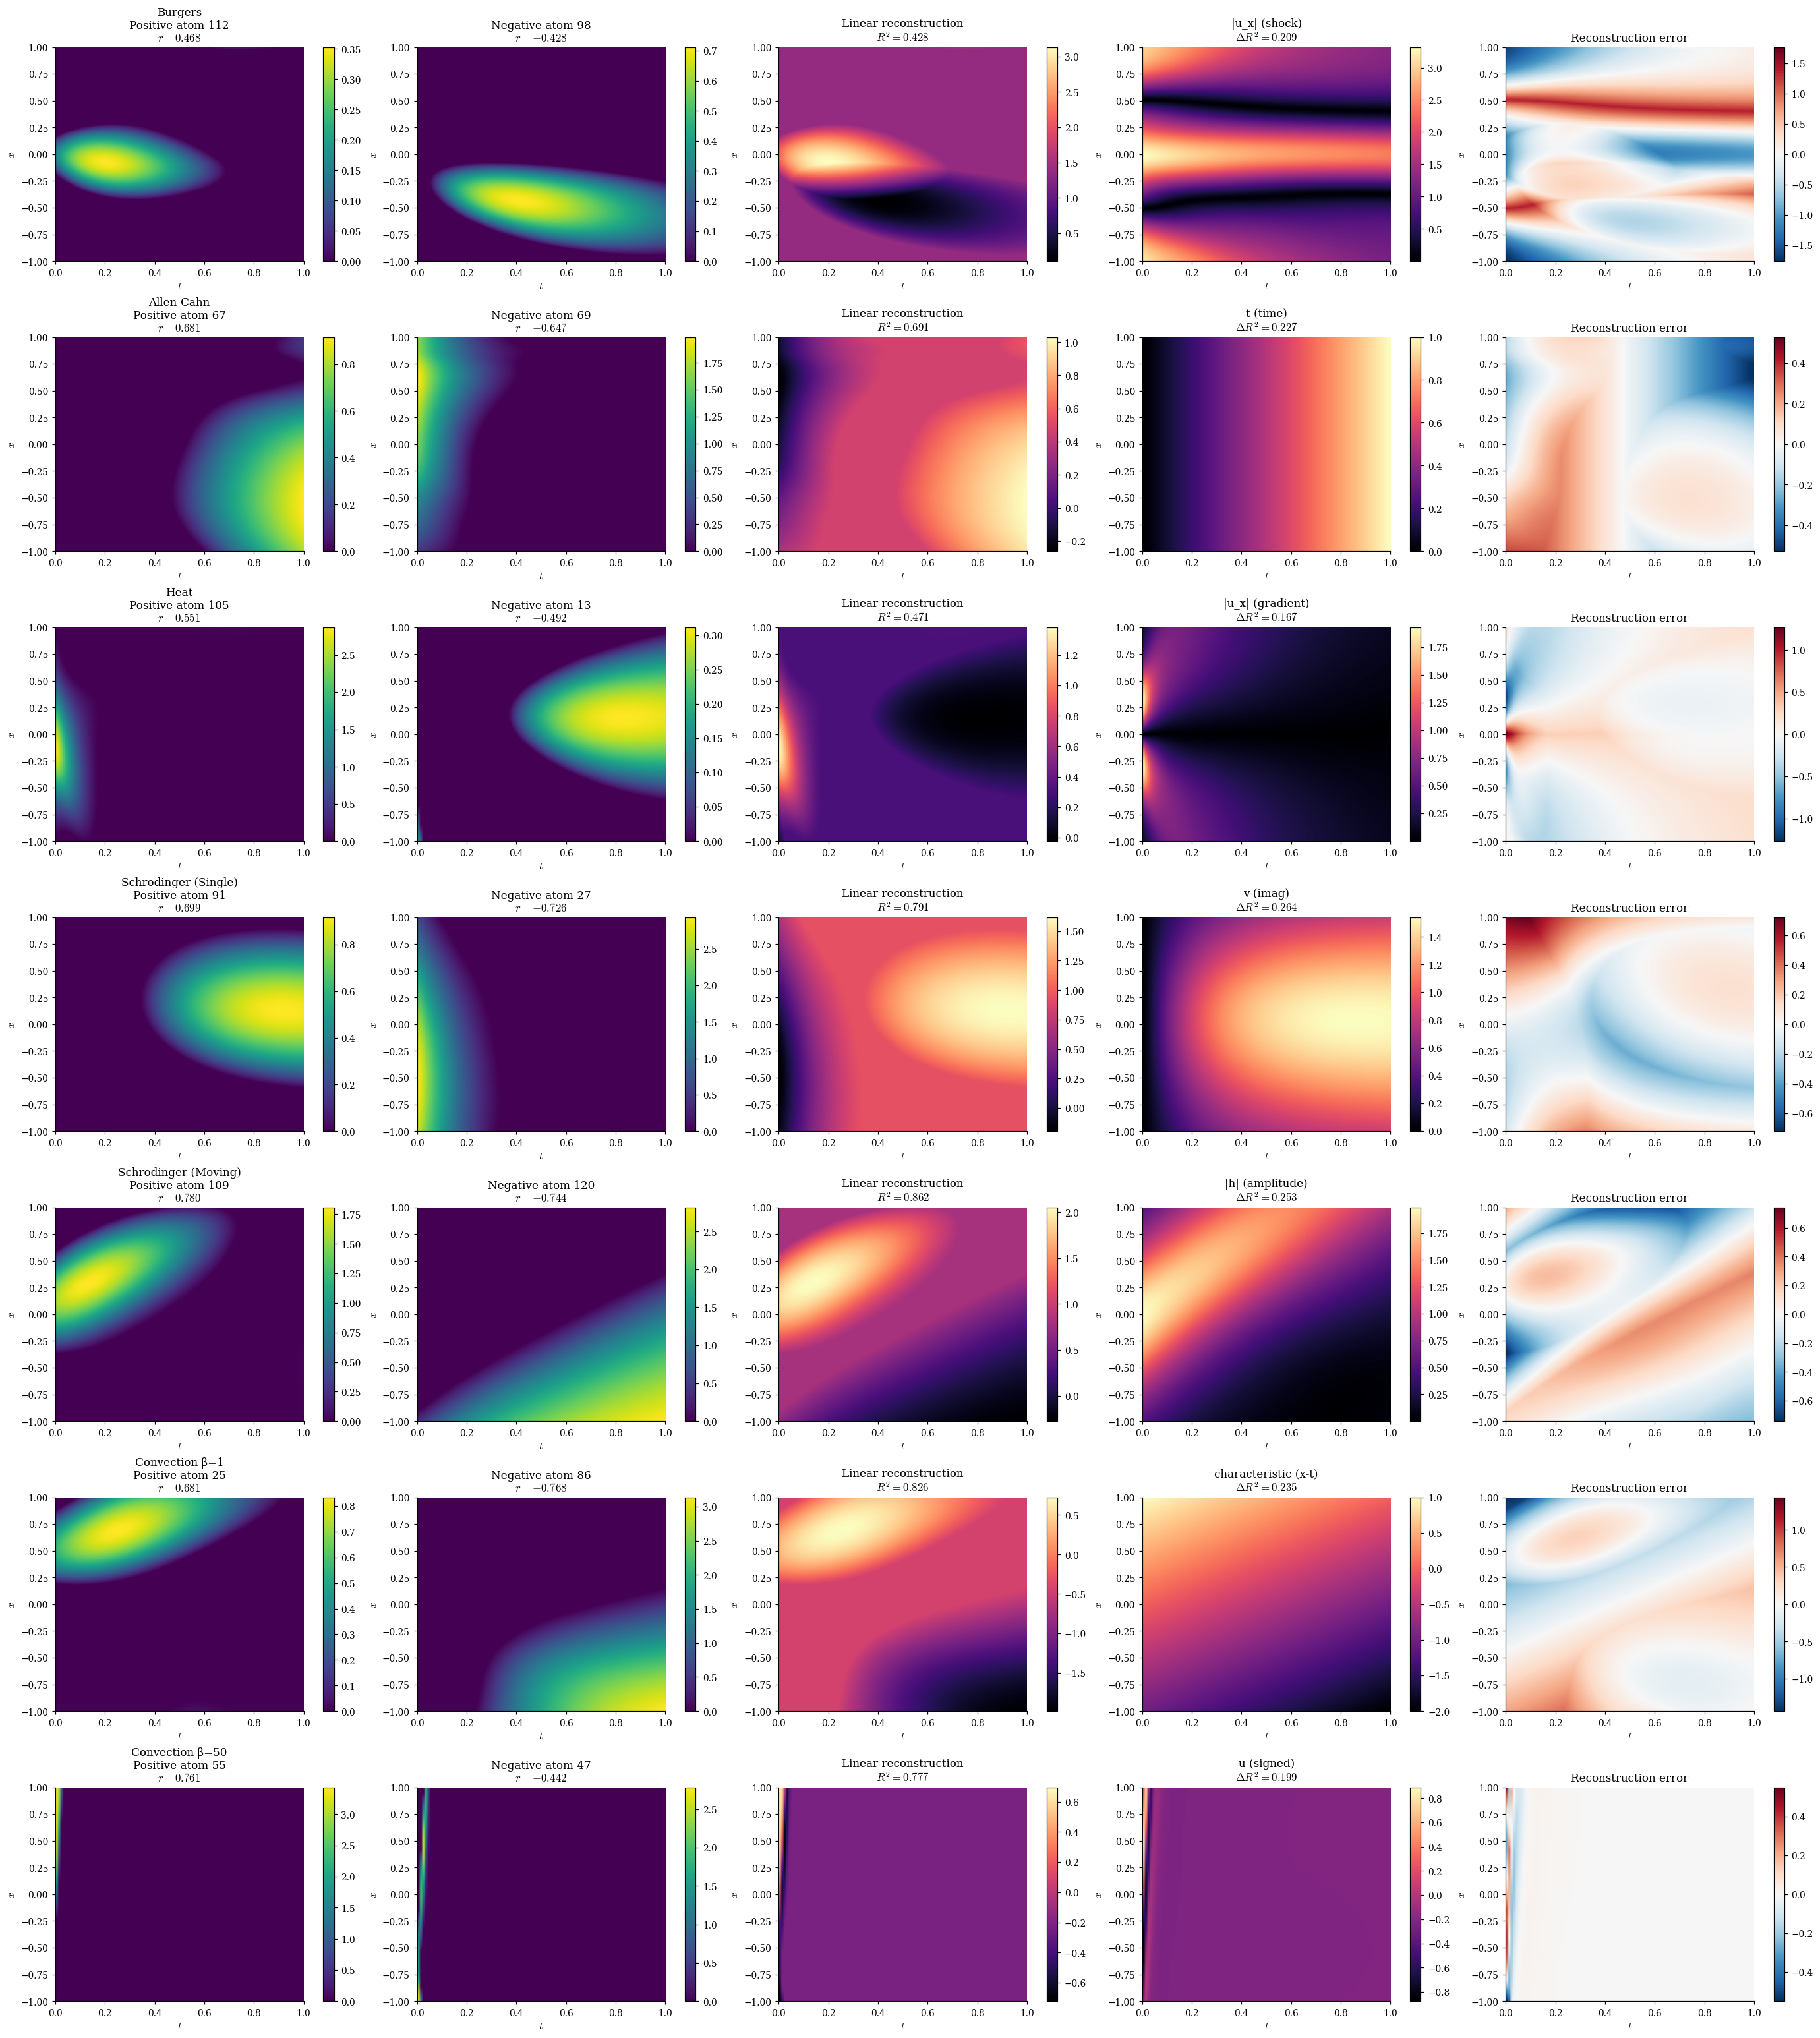

In [39]:
extent = [ts_np.min(), ts_np.max(), xs_np.min(), xs_np.max()]
extent_s = [ts_s_np.min(), ts_s_np.max(), xs_s_np.min(), xs_s_np.max()]

fig_two_sided_auto([

    (Z_b, C_b, names_b, two_b, cmp_b, "Burgers"),

    (Z_a, C_a, names_a, two_a, cmp_a, "Allen-Cahn"),

    (Z_h, C_h, names_h, two_h, cmp_h, "Heat"),

    (Z_s_s, C_s_s, names_s_s, two_s_s, cmp_s_s, "Schrodinger (Single)"),

    (Z_s_m, C_s_m, names_s_m, two_s_m, cmp_s_m, "Schrodinger (Moving)"),

    (Z_c1, C_c1, names_c1, two_c1, cmp_c1, "Convection β=1"),

    (Z_c50, C_c50, names_c50, two_c50, cmp_c50, "Convection β=50")

])